# **Making Lending Decisions Understandable**

---



# **Logistic Regression Model**

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [8]:
!git clone https://github.com/anjaliv-22/-Making-Lending-Decisions-Understandable.git

Cloning into '-Making-Lending-Decisions-Understandable'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 20 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 187.82 KiB | 3.91 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [9]:
LC = pd.read_csv("-Making-Lending-Decisions-Understandable/loan_data.csv")

In [10]:
LC.columns = LC.columns.str.strip()
LC['int.rate'] = LC['int.rate'].astype(str).str.rstrip('%').astype(float) / 100


X = LC[['fico', 'int.rate', 'installment', 'log.annual.inc']]
y = LC['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.5542797494780793


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.53      0.67      2408
           1       0.22      0.67      0.33       466

    accuracy                           0.55      2874
   macro avg       0.55      0.60      0.50      2874
weighted avg       0.78      0.55      0.61      2874



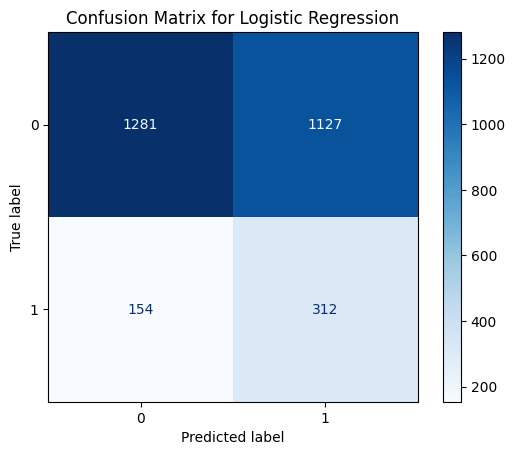

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

# **XG Boost Model**

In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.7 MB/s eta 0:00:00


In [41]:
num_negative = (y_train == 0).sum()

num_positive = (y_train == 1).sum()

spw = num_negative / num_positive

print (spw)

5.283036551077788


In [52]:
### 1. XGBoost Tuning Code (from tune_xgboost.py)

#This is the core objective function we passed to Optuna. It searches for tree structure parameters (max_depth, min_child_weight), regularization terms (reg_alpha, reg_lambda), learning rate, and sampling rates.



#`python

import optuna

import xgboost as xgb

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Calculate scale_pos_weight (spw)

# (Number of non-defaulted loans / Number of defaulted loans)

num_negative = (y_train == 0).sum()

num_positive = (y_train == 1).sum()

spw = num_negative / num_positive



print(f"Scale Position Weight (spw) is: {spw:.3f}")



def make_objective(X_train, y_train, scale_pos_weight, cv):

    def objective(trial):

        params = {



            'n_estimators':      trial.suggest_categorical('n_estimators', [50, 100, 250, 500]),

            'max_depth':         trial.suggest_categorical('max_depth', [3, 5, 8]),

            'learning_rate':     trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1]),



            # Sampling parameters (adds randomness to prevent overfitting)

            'subsample':         trial.suggest_categorical('subsample', [0.6, 0.8, 1.0]),

            'colsample_bytree':  trial.suggest_categorical('colsample_bytree', [0.6, 0.8, 1.0]),

            'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),



            # Regularisation parameters

            'gamma':             trial.suggest_float('gamma', 0.0, 0.5),

            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),

            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),



            'scale_pos_weight':  spw,  # To handle class imbalance

            'random_state':      42,

            'verbosity':         0,

            'eval_metric':       'logloss',

        }



        # Train and validate using K-Fold CV

        model = xgb.XGBClassifier(**params)

        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

        return scores.mean()

    return objective



# --- Running the study ---

cv = StratifiedKFold(5, shuffle=True, random_state=42)

study = optuna.create_study(direction='maximize')

study.optimize(make_objective(X_train, y_train, spw, cv), n_trials=100)



print("Best XGB Parameters:", study.best_params)

print("Best ROC-AUC:", study.best_value)

[I 2026-06-19 23:13:03,712] A new study created in memory with name: no-name-4cde3075-d071-4416-8c78-b4eb984bba25


Scale Position Weight (spw) is: 5.283


[I 2026-06-19 23:13:12,892] Trial 0 finished with value: 0.5978296511405281 and parameters: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 10, 'gamma': 0.32749595901319883, 'reg_alpha': 0.04936682241591171, 'reg_lambda': 4.679789978206881e-06}. Best is trial 0 with value: 0.5978296511405281.
[I 2026-06-19 23:13:14,824] Trial 1 finished with value: 0.5940682592079384 and parameters: {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_weight': 3, 'gamma': 0.25553193487726894, 'reg_alpha': 0.005436351551487574, 'reg_lambda': 7.694059811856926}. Best is trial 0 with value: 0.5978296511405281.
[I 2026-06-19 23:13:18,467] Trial 2 finished with value: 0.5874585080596247 and parameters: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0.2662803786212268, 'reg_alpha': 3.4

Best XGB Parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_weight': 10, 'gamma': 0.020041802645660495, 'reg_alpha': 6.881840720900052, 'reg_lambda': 4.820546244042033e-06}
Best ROC-AUC: 0.6317594947449632


In [81]:
# params1: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_weight': 6, 'gamma': 0.12378956137115626, 'reg_alpha': 1.207359257869829e-07, 'reg_lambda': 0.00019260709364697732}
params1: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_weight': 10, 'gamma': 0.020041802645660495, 'reg_alpha': 6.881840720900052, 'reg_lambda': 4.820546244042033e-06}

Bestmodel = xgb.XGBClassifier(**params1)


In [82]:
Bestmodel.fit(X_train, y_train)
y_pred_xgb = Bestmodel.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_xgb)
print(accuracy)

0.6099512874043146


In [83]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.63      0.73      2408
           1       0.21      0.50      0.29       466

    accuracy                           0.61      2874
   macro avg       0.54      0.56      0.51      2874
weighted avg       0.76      0.61      0.66      2874



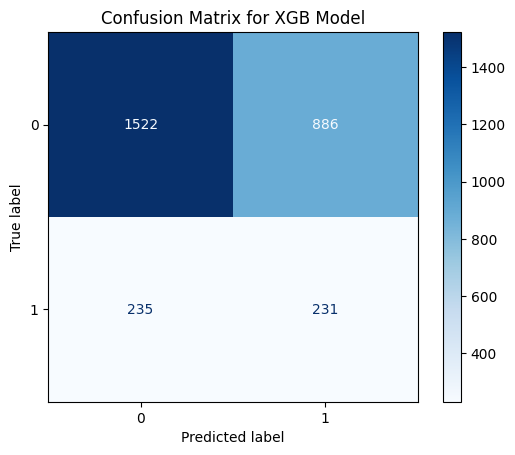

In [86]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for XGB Model")
plt.show()